In [19]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import defaultdict
import copy
from pathlib import Path
# from google.colab import drive

### Load Kaggle MNIST dataset

In [20]:
# load the dataset from my local parent directory
MNIST_DIR = str(Path("../ReducedMNIST_kaggle/Reduced MNIST Data").resolve())

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [22]:
data_root = Path(MNIST_DIR)
train_dir = data_root / "Reduced Training data"
test_dir  = data_root / "Reduced Testing data"

# Base transform — no augmentation, just resize for LeNet-5
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

full_train_dataset = datasets.ImageFolder(root=str(train_dir), transform=base_transform)
test_dataset       = datasets.ImageFolder(root=str(test_dir),  transform=base_transform)

print(f"Full training set: {len(full_train_dataset)} images")
print(f"Test set:          {len(test_dataset)} images")
print(f"Classes:           {full_train_dataset.classes}")

Full training set: 10000 images
Test set:          2000 images
Classes:           ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [23]:
# Pre-load ALL images into memory ONCE
print("Pre-loading all training images into memory...")
all_train_imgs, all_train_labels = [], []
for i in range(len(full_train_dataset)):
    img, label = full_train_dataset[i]
    all_train_imgs.append(img)
    all_train_labels.append(label)
    if (i + 1) % 2000 == 0:
        print(f"  {i+1}/{len(full_train_dataset)} loaded")
all_train_imgs = torch.stack(all_train_imgs)
all_train_labels = torch.tensor(all_train_labels)
print(f"Done! {all_train_imgs.shape} training images in memory.\n")

print("Pre-loading test images into memory...")
all_test_imgs, all_test_labels = [], []
for i in range(len(test_dataset)):
    img, label = test_dataset[i]
    all_test_imgs.append(img)
    all_test_labels.append(label)
all_test_imgs = torch.stack(all_test_imgs)
all_test_labels = torch.tensor(all_test_labels)
print(f"Done! {all_test_imgs.shape} test images in memory.")

Pre-loading all training images into memory...
  2000/10000 loaded
  4000/10000 loaded
  6000/10000 loaded
  8000/10000 loaded
  10000/10000 loaded
Done! torch.Size([10000, 1, 32, 32]) training images in memory.

Pre-loading test images into memory...
Done! torch.Size([2000, 1, 32, 32]) test images in memory.


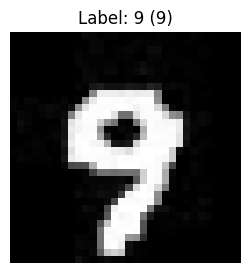

In [24]:
# pick a random sample from the training dataset
idx = random.randrange(len(full_train_dataset))
img, label = full_train_dataset[idx]

# show image
plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label} ({full_train_dataset.classes[label]})")
plt.axis("off")
plt.show()

## 1. Helper: Subsample real data per digit

In [25]:
def subsample_indices(labels, num_per_digit, seed=42):
    """Return indices for num_per_digit examples per class from a label tensor."""
    rng = random.Random(seed)
    selected = []
    for digit in range(10):
        indices = (labels == digit).nonzero(as_tuple=True)[0].tolist()
        chosen = rng.sample(indices, min(num_per_digit, len(indices)))
        selected.extend(chosen)
    return selected

# Quick test
idx350 = subsample_indices(all_train_labels, 350)
print(f"Subsampled to 350/digit: {len(idx350)} total indices")

Subsampled to 350/digit: 3500 total indices


## 2. Augmentation Pipeline

Generate new examples from real data using:
- **Random rotation** (±5° to ±15°)
- **Random affine translation** (shift by δx, δy)
- **Additive Gaussian white noise**

In [ ]:
augmentation_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),                         # rotate ±15°
    transforms.RandomAffine(degrees=5, translate=(0.1, 0.1)),      # small shift + ±5° extra
])

def add_white_noise(tensor, noise_fraction=0.05):
    """Add Gaussian white noise (noise_fraction of pixel range)."""
    noise = torch.randn_like(tensor) * noise_fraction
    return torch.clamp(tensor + noise, 0.0, 1.0)

def cache_subset(subset):
    """Load all images from a Subset into memory as (tensor, label) lists per class."""
    class_images = defaultdict(list)
    for idx in range(len(subset)):
        img, label = subset[idx]
        class_images[label].append(img)
    return class_images

class OnTheFlyAugDataset(torch.utils.data.Dataset):
    """Generates augmented images on-the-fly from cached real images (no pre-generation)."""
    def __init__(self, cached_class_images, num_per_digit):
        self.cached = cached_class_images
        self.num_per_digit = num_per_digit
        self.labels = sorted(cached_class_images.keys())
        self.total = num_per_digit * len(self.labels)

    def __len__(self):
        return self.total

    def __getitem__(self, idx):
        label = self.labels[idx // self.num_per_digit]
        real_imgs = self.cached[label]
        base_img = real_imgs[torch.randint(len(real_imgs), (1,)).item()]
        pil_img = transforms.ToPILImage()(base_img)
        aug_img = augmentation_transform(pil_img)
        aug_tensor = transforms.ToTensor()(aug_img)
        aug_tensor = add_white_noise(aug_tensor, noise_fraction=0.05)
        return aug_tensor, label

print("Augmentation pipeline defined.")

Augmentation pipeline defined (on-the-fly, no pre-generation).


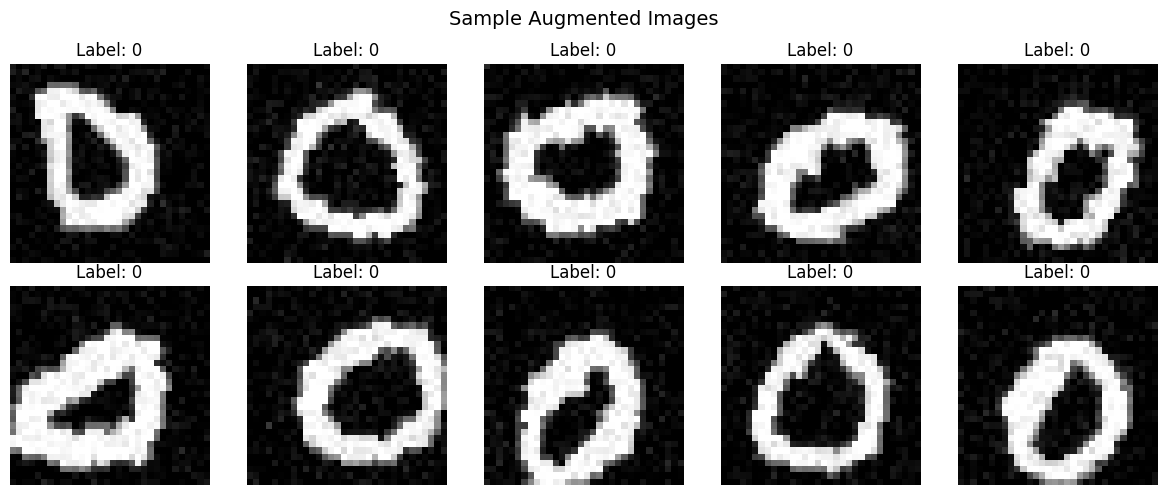

In [27]:
# Visualize a few augmented examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Augmented Images", fontsize=14)

for i in range(10):
    img, label = full_train_dataset[i * 100]  # grab one image per digit
    pil_img = transforms.ToPILImage()(img)
    aug_img = augmentation_transform(pil_img)
    aug_tensor = add_white_noise(transforms.ToTensor()(aug_img), 0.05)
    ax = axes[i // 5][i % 5]
    ax.imshow(aug_tensor.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. LeNet-5 Model Definition

In [28]:
class LeNet5(nn.Module):
    """Classic LeNet-5 for 1-channel 32x32 input, 10 classes."""
    def __init__(self):
        super(LeNet5, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),       # 32->28
            nn.ReLU(),
            nn.AvgPool2d(2, 2),                   # 28->14
            nn.Conv2d(6, 16, kernel_size=5),      # 14->10
            nn.ReLU(),
            nn.AvgPool2d(2, 2),                   # 10->5
        )
        self.classifier = nn.Sequential(
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

print("LeNet-5 architecture:")
print(LeNet5())

LeNet-5 architecture:
LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)


## 4. Training & Evaluation Functions

In [29]:
def train_model(model, train_loader, device, epochs=15, lr=0.001):
    """Train model and return training loss and accuracy history."""
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    acc_history = []
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = 100.0 * correct / total
        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:2d}/{epochs}] Loss: {epoch_loss:.4f}  Train Acc: {epoch_acc:.2f}%")

    return loss_history, acc_history


def evaluate_model(model, test_loader, device):
    """Evaluate model on test set. Returns accuracy (%)."""
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    accuracy = 100.0 * correct / total
    return accuracy

print("Training & evaluation functions defined.")

Training & evaluation functions defined.


## 5. Run All 12 Experiments

**Experiment grid:**
- Real data per digit: **350, 750, 1000**
- Generated (augmented) per digit: **0, 1000, 1500, 2000**

All experiments are tested on the **same 2000 test images** (200 per digit).

In [30]:
# Experiment configuration
real_counts = [350, 750, 1000]
gen_counts  = [0, 1000, 1500, 2000]
EPOCHS      = 15
BATCH_SIZE  = 64
SEED        = 42

# Test loader (in-memory TensorDataset — no disk reads)
test_ds = TensorDataset(all_test_imgs, all_test_labels)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Store results: results[gen_count][real_count] = accuracy
results = defaultdict(dict)
# Store learning curves: curves[(real_n, gen_n)] = {'loss': [...], 'acc': [...]}
curves = {}

def pregenerate_augmented(real_imgs_by_class, num_per_digit):
    """Pre-generate augmented images as tensors from in-memory class dict."""
    aug_imgs, aug_labels = [], []
    for label in sorted(real_imgs_by_class.keys()):
        imgs = real_imgs_by_class[label]
        n = len(imgs)
        for _ in range(num_per_digit):
            base_img = imgs[torch.randint(n, (1,)).item()]
            pil_img = transforms.ToPILImage()(base_img)
            aug_img = augmentation_transform(pil_img)
            aug_tensor = transforms.ToTensor()(aug_img)
            aug_tensor = add_white_noise(aug_tensor, noise_fraction=0.05)
            aug_imgs.append(aug_tensor)
            aug_labels.append(label)
    return torch.stack(aug_imgs), torch.tensor(aug_labels)

for real_n in real_counts:
    real_idx = subsample_indices(all_train_labels, real_n, seed=SEED)
    real_imgs = all_train_imgs[real_idx]
    real_labels = all_train_labels[real_idx]

    print(f"\n{'='*60}")
    print(f"Real data per digit: {real_n}  (total real: {len(real_imgs)})")
    print(f"{'='*60}")

    # Group cached images by class (purely in-memory)
    cached = defaultdict(list)
    for img, lbl in zip(real_imgs, real_labels):
        cached[lbl.item()].append(img)

    for gen_n in gen_counts:
        print(f"\n--- Generated per digit: {gen_n} ---")
        if gen_n == 0:
            train_imgs, train_labels = real_imgs, real_labels
        else:
            aug_imgs, aug_labels = pregenerate_augmented(cached, gen_n)
            train_imgs = torch.cat([real_imgs, aug_imgs])
            train_labels = torch.cat([real_labels, aug_labels])

        print(f"  Total training samples: {len(train_imgs)}")
        train_ds = TensorDataset(train_imgs, train_labels)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

        model = LeNet5()
        loss_hist, acc_hist = train_model(model, train_loader, device, epochs=EPOCHS)
        acc = evaluate_model(model, test_loader, device)
        results[gen_n][real_n] = acc
        curves[(real_n, gen_n)] = {'loss': loss_hist, 'acc': acc_hist}
        print(f"  >> Test Accuracy: {acc:.2f}%")

print("\n\nAll experiments completed!")


Real data per digit: 350  (total real: 3500)

--- Generated per digit: 0 ---
  Total training samples: 3500
  Epoch [ 1/15] Loss: 1.7209  Train Acc: 45.31%
  Epoch [ 5/15] Loss: 0.2809  Train Acc: 91.43%
  Epoch [10/15] Loss: 0.1557  Train Acc: 95.46%
  Epoch [15/15] Loss: 0.0855  Train Acc: 97.49%
  >> Test Accuracy: 96.35%

--- Generated per digit: 1000 ---
  Total training samples: 13500
  Epoch [ 1/15] Loss: 1.0933  Train Acc: 63.79%
  Epoch [ 5/15] Loss: 0.1552  Train Acc: 95.08%
  Epoch [10/15] Loss: 0.0749  Train Acc: 97.37%
  Epoch [15/15] Loss: 0.0353  Train Acc: 98.81%
  >> Test Accuracy: 96.80%

--- Generated per digit: 1500 ---
  Total training samples: 18500
  Epoch [ 1/15] Loss: 1.0160  Train Acc: 66.19%
  Epoch [ 5/15] Loss: 0.1548  Train Acc: 94.80%
  Epoch [10/15] Loss: 0.0804  Train Acc: 97.34%
  Epoch [15/15] Loss: 0.0394  Train Acc: 98.64%
  >> Test Accuracy: 96.45%

--- Generated per digit: 2000 ---
  Total training samples: 23500
  Epoch [ 1/15] Loss: 1.0447  Tra

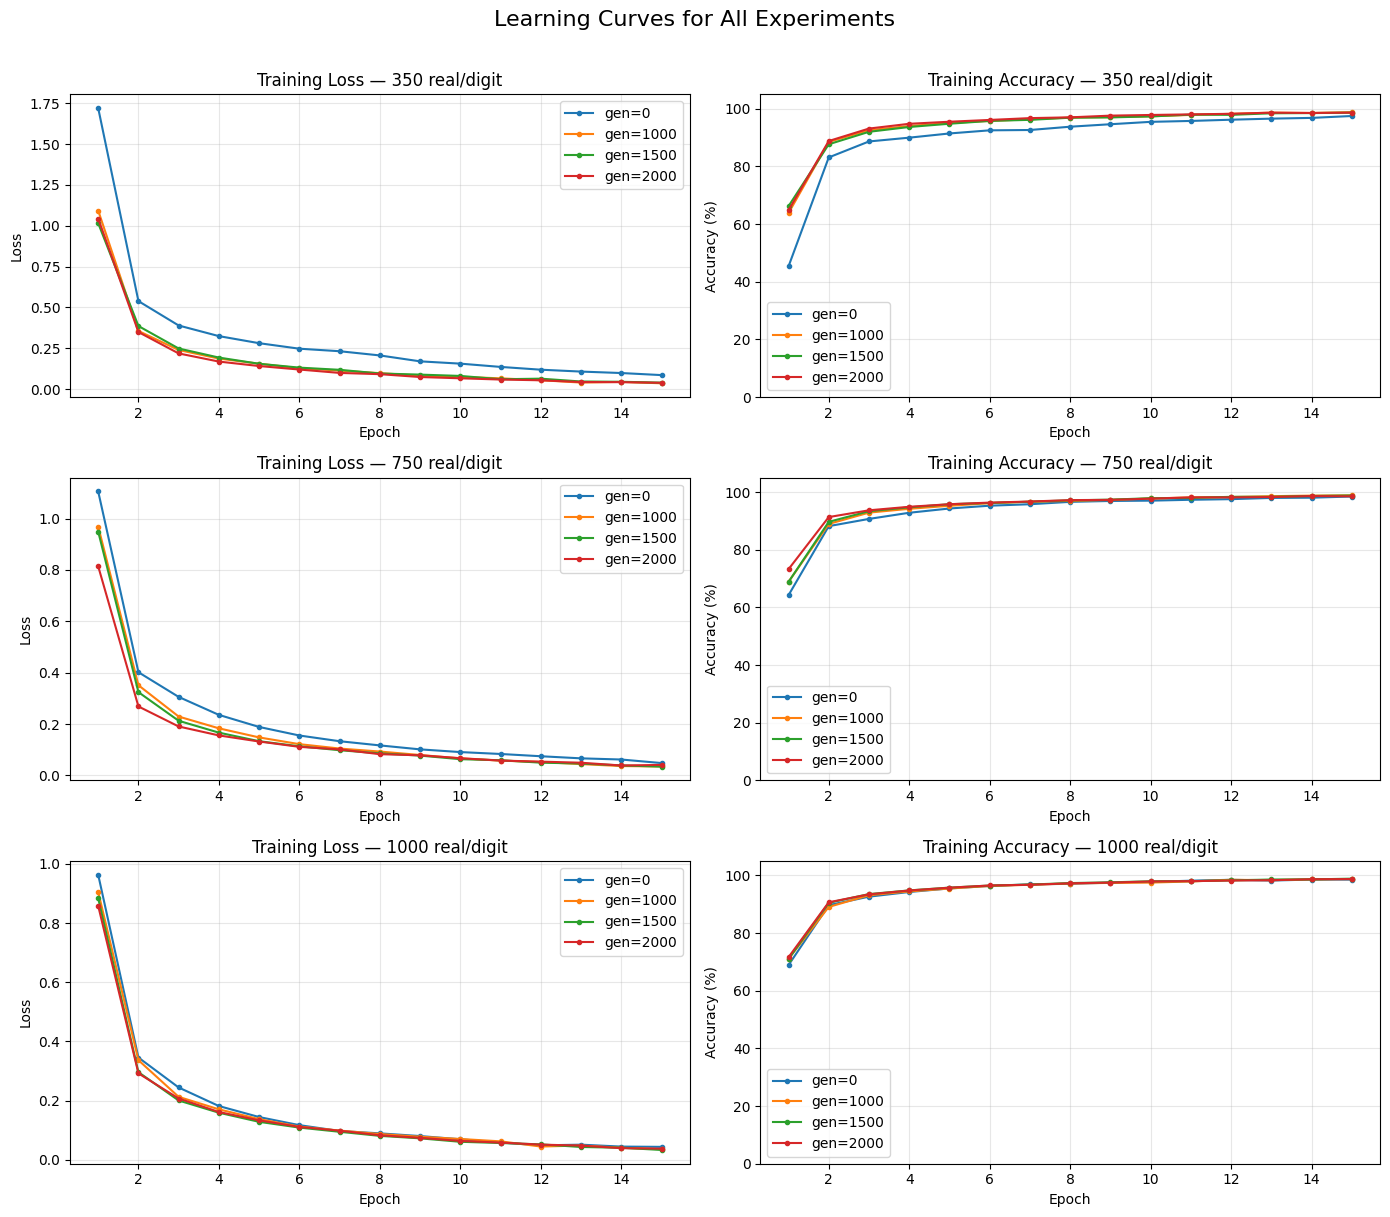

In [33]:
# Plot learning curves for all 12 experiments
fig, axes = plt.subplots(len(real_counts), 2, figsize=(14, 4 * len(real_counts)))
fig.suptitle("Learning Curves for All Experiments", fontsize=16, y=1.01)

for row, real_n in enumerate(real_counts):
    ax_loss = axes[row, 0]
    ax_acc = axes[row, 1]

    for gen_n in gen_counts:
        key = (real_n, gen_n)
        epochs_range = range(1, EPOCHS + 1)
        label = f"gen={gen_n}"
        ax_loss.plot(epochs_range, curves[key]['loss'], marker='o', markersize=3, label=label)
        ax_acc.plot(epochs_range, curves[key]['acc'], marker='o', markersize=3, label=label)

    ax_loss.set_title(f"Training Loss — {real_n} real/digit")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.set_title(f"Training Accuracy — {real_n} real/digit")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## 6. Results Table & Analysis


           RESULTS TABLE — Test Accuracy (%) on 2000 test images           
      Gen/digit |       350 real |       750 real |      1000 real
------------------------------------------------------------------
              0 |         96.35% |         97.00% |         96.90% |
           1000 |         96.80% |         97.80% |         98.10% |
           1500 |         96.45% |         97.90% |         98.10% |
           2000 |         97.20% |         98.55% |         97.80% |


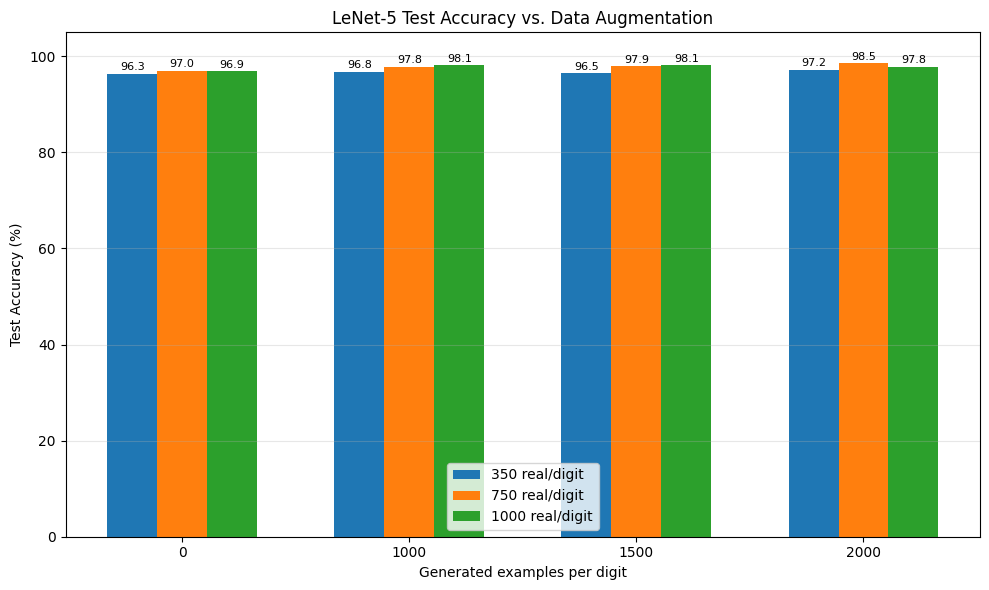

In [34]:
# ---------- Print results table ----------
print(f"\n{'='*75}")
print(f"{'RESULTS TABLE — Test Accuracy (%) on 2000 test images':^75}")
print(f"{'='*75}")

header = f"{'Gen/digit':>15} | {'350 real':>14} | {'750 real':>14} | {'1000 real':>14}"
print(header)
print("-" * len(header))
for gen_n in gen_counts:
    row = f"{gen_n:>15} |"
    for real_n in real_counts:
        acc = results[gen_n][real_n]
        row += f" {acc:>13.2f}% |"
    print(row)
print(f"{'='*75}")

# ---------- Bar chart comparison ----------
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(gen_counts))
width = 0.22

for i, real_n in enumerate(real_counts):
    accs = [results[g][real_n] for g in gen_counts]
    bars = ax.bar(x + i * width, accs, width, label=f"{real_n} real/digit")
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{acc:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Generated examples per digit")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("LeNet-5 Test Accuracy vs. Data Augmentation")
ax.set_xticks(x + width)
ax.set_xticklabels([str(g) for g in gen_counts])
ax.legend()
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Comments on Results

**Key observations:**

1. **More real data helps**: Across all augmentation levels, using more real data per digit (350 → 750 → 1000) consistently improves test accuracy, as real data captures true distribution better than synthetic data.

2. **Augmentation boosts low-data regimes most**: When real data is scarce (350/digit), adding generated examples provides the largest accuracy gains. The model benefits from seeing more diverse versions of the limited real samples.

3. **Diminishing returns at high augmentation**: Going from 1500 to 2000 generated examples shows smaller improvements than going from 0 to 1000. The augmented images are derived from the same base images, so after a point the model has already learned the available variation.

4. **Augmentation is "free" labeling**: Since augmented images inherit labels from their source, we gain training data without any manual labeling cost — only compute time. This makes augmentation especially valuable when labeling is expensive.

5. **With enough real data, augmentation still helps**: Even with 1000 real examples/digit, adding augmented data improves generalization by introducing small perturbations (rotation, translation, noise) that act as regularization.